# 06 — Modelagem Comparativa

Este notebook desenvolve e compara os quatro classificadores definidos no estudo:

- Regressão Logística;
- K-Nearest Neighbors (KNN);
- Random Forest;
- Gradient Boosting.

A comparação respeita o particionamento temporal estabelecido na preparação dos dados.

## Princípios metodológicos

1. O conjunto de **treino** é utilizado para ajuste dos modelos e seleção de hiperparâmetros.
2. A seleção de hiperparâmetros é realizada por **validação temporal interna**, sem embaralhamento dos registros.
3. Todo pré-processamento dependente dos dados é ajustado dentro do `Pipeline`, exclusivamente nos dados disponíveis em cada dobra de treinamento.
4. O conjunto de **teste** é utilizado somente após o encerramento da seleção de hiperparâmetros, para comparação inicial dos modelos.
5. O conjunto **out-of-time (OOT)** permanece isolado e não é utilizado neste notebook.
6. A seleção de hiperparâmetros utiliza **PR-AUC (Average Precision)** como critério de refit, por ser uma medida independente do threshold e informativa em problemas com alteração na prevalência da classe.
7. A **Precisão da classe Resolvida** permanece como principal métrica classificatória de interesse do negócio e será analisada conjuntamente com Revocação, F1, ROC-AUC, PR-AUC e KS.
8. O threshold inicial de classificação é mantido em `0,50`. Ajustes de threshold, se necessários, serão tratados em etapa posterior e sem acesso ao OOT.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
N_JOBS = -1

print(f"scikit-learn: {sklearn.__version__}")


scikit-learn: 1.9.1


## 2. Diretórios e carregamento da base


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")
PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"

FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"
MODELS_DIR = PROJECT_DIR / "outputs" / "modelos"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {INPUT_FILE}. "
        "Execute primeiro o notebook 03_preparacao_dados.ipynb."
    )

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Base carregada: {len(df):,} registros x {df.shape[1]} colunas")


Base carregada: 58,131 registros x 16 colunas


## 3. Preditores, target e partições

O OOT é apenas quantificado nesta etapa. Suas observações não são materializadas nas matrizes de desenvolvimento.


In [3]:
PREDITORES = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

TARGET = "target"

colunas_necessarias = PREDITORES + [
    TARGET,
    "AAAA_MM",
    "Amostra"
]

faltantes = [
    coluna for coluna in colunas_necessarias
    if coluna not in df.columns
]

if faltantes:
    raise KeyError(f"Colunas ausentes: {faltantes}")

df_train = (
    df[df["Amostra"] == "Treino"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

df_test = (
    df[df["Amostra"] == "Teste"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

n_oot_reservado = int(
    (df["Amostra"] == "OOT").sum()
)

X_train = df_train[PREDITORES].copy()
y_train = df_train[TARGET].astype(int).copy()

X_test = df_test[PREDITORES].copy()
y_test = df_test[TARGET].astype(int).copy()

print(f"Treino: {len(df_train):,} registros")
print(f"Teste:  {len(df_test):,} registros")
print(f"OOT reservado e não utilizado: {n_oot_reservado:,} registros")
print()
print(f"Resolvida no treino: {y_train.mean() * 100:.2f}%")
print(f"Resolvida no teste:  {y_test.mean() * 100:.2f}%")


Treino: 12,032 registros
Teste:  14,027 registros
OOT reservado e não utilizado: 32,072 registros

Resolvida no treino: 45.76%
Resolvida no teste:  38.46%


## 4. Validação temporal interna

Os 24 meses de treinamento são utilizados em um esquema de janela temporal expansiva.

A configuração adotada é:

- Dobra 1: primeiros 12 meses para ajuste e 4 meses seguintes para validação;
- Dobra 2: primeiros 16 meses para ajuste e 4 meses seguintes para validação;
- Dobra 3: primeiros 20 meses para ajuste e 4 meses finais para validação.

Assim, todas as validações ocorrem cronologicamente após os dados utilizados no respectivo ajuste.


In [4]:
meses_treino = sorted(
    df_train["AAAA_MM"].dropna().unique()
)

if len(meses_treino) != 24:
    raise ValueError(
        f"Esperavam-se 24 meses de treino, mas foram encontrados {len(meses_treino)}."
    )

config_folds = [
    (12, 4),
    (16, 4),
    (20, 4)
]

cv_temporal = []
resumo_folds = []

for numero_fold, (n_meses_ajuste, n_meses_validacao) in enumerate(
    config_folds,
    start=1
):
    meses_ajuste = meses_treino[:n_meses_ajuste]
    meses_validacao = meses_treino[
        n_meses_ajuste:
        n_meses_ajuste + n_meses_validacao
    ]

    idx_ajuste = np.flatnonzero(
        df_train["AAAA_MM"].isin(meses_ajuste)
    )

    idx_validacao = np.flatnonzero(
        df_train["AAAA_MM"].isin(meses_validacao)
    )

    cv_temporal.append(
        (idx_ajuste, idx_validacao)
    )

    resumo_folds.append({
        "Fold": numero_fold,
        "Treino de": meses_ajuste[0],
        "Treino até": meses_ajuste[-1],
        "Meses treino": len(meses_ajuste),
        "Registros treino": len(idx_ajuste),
        "Validação de": meses_validacao[0],
        "Validação até": meses_validacao[-1],
        "Meses validação": len(meses_validacao),
        "Registros validação": len(idx_validacao)
    })

resumo_cv = pd.DataFrame(resumo_folds)

display(resumo_cv)

resumo_cv.to_csv(
    TABLES_DIR / "modelagem_folds_validacao_temporal.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Fold,Treino de,Treino até,Meses treino,Registros treino,Validação de,Validação até,Meses validação,Registros validação
0,1,2022_08,2023_07,12,5388,2023_08,2023_11,4,2264
1,2,2022_08,2023_11,16,7652,2023_12,2024_03,4,1869
2,3,2022_08,2024_03,20,9521,2024_04,2024_07,4,2511


## 5. Métricas utilizadas durante o desenvolvimento

O critério de `refit` será a **PR-AUC (Average Precision)**.

A escolha evita que hiperparâmetros sejam selecionados exclusivamente a partir de um threshold fixo. Ainda assim, Precisão, Revocação, F1 e ROC-AUC são calculadas em cada dobra para permitir análise conjunta.


In [5]:
scoring = {
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

REFIT_METRIC = "pr_auc"


## 6. Funções auxiliares de pré-processamento

### 6.1 One-Hot Encoding

Regressão Logística, Random Forest e Gradient Boosting utilizarão inicialmente One-Hot Encoding para preservar a natureza nominal dos atributos.

O parâmetro `min_frequency` será tratado como parte do processo de desenvolvimento e avaliado **dentro da validação temporal**.

### 6.2 KNN

Para o KNN será utilizada codificação ordinal apenas como representação computacional, acompanhada da distância de **Hamming**. Dessa forma, os valores numéricos atribuídos às categorias não são interpretados como ordem ou magnitude: a distância verifica somente se duas categorias são iguais ou diferentes.

Como categorias desconhecidas são representadas por um mesmo valor sentinela, será comparada, ainda dentro da validação temporal, uma especificação com `Cidade` e outra sem `Cidade`, atributo que apresentou maior incidência de categorias futuras.


In [6]:
def criar_ohe(esparso=True):
    kwargs = {
        "handle_unknown": "infrequent_if_exist",
        "min_frequency": None
    }

    try:
        return OneHotEncoder(
            sparse_output=esparso,
            **kwargs
        )
    except TypeError:
        return OneHotEncoder(
            sparse=esparso,
            **kwargs
        )


def criar_preprocessador_ohe(colunas, esparso=True):
    return ColumnTransformer(
        transformers=[
            (
                "cat",
                criar_ohe(esparso=esparso),
                colunas
            )
        ],
        remainder="drop"
    )


def criar_encoder_knn():
    return OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )


## 7. Função para executar e registrar GridSearchCV

Os grids são deliberadamente moderados. O objetivo é comparar os quatro algoritmos sob um protocolo comum, evitando uma busca excessivamente ampla nesta etapa.


In [7]:
def executar_grid(
    nome_modelo,
    pipeline,
    param_grid,
    X,
    y,
    n_jobs=N_JOBS
):
    print("=" * 80)
    print(f"Modelo: {nome_modelo}")
    print("=" * 80)

    busca = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=REFIT_METRIC,
        cv=cv_temporal,
        n_jobs=n_jobs,
        return_train_score=False,
        verbose=1
    )

    busca.fit(X, y)

    resultados_cv = pd.DataFrame(
        busca.cv_results_
    ).sort_values(
        "rank_test_pr_auc"
    )

    print()
    print(f"Melhor PR-AUC média na validação temporal: {busca.best_score_:.4f}")
    print("Melhores hiperparâmetros:")
    print(busca.best_params_)

    return busca, resultados_cv


## 8. Regressão Logística


In [8]:
preprocessador_logistica = criar_preprocessador_ohe(
    PREDITORES,
    esparso=True
)

pipeline_logistica = Pipeline(
    steps=[
        ("preprocessamento", preprocessador_logistica),
        (
            "modelo",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=3000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

grid_logistica = {
    "preprocessamento__cat__min_frequency": [
        None,
        5,
        10
    ],
    "modelo__C": [
        0.1,
        1.0,
        10.0
    ],
    "modelo__class_weight": [
        None,
        "balanced"
    ]
}

busca_logistica, cv_logistica = executar_grid(
    "Regressão Logística",
    pipeline_logistica,
    grid_logistica,
    X_train,
    y_train
)

cv_logistica.to_csv(
    TABLES_DIR / "cv_regressao_logistica.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


Modelo: Regressão Logística
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Melhor PR-AUC média na validação temporal: 0.5947
Melhores hiperparâmetros:
{'modelo__C': 0.1, 'modelo__class_weight': None, 'preprocessamento__cat__min_frequency': 10}


## 9. K-Nearest Neighbors — especificação com Cidade

O KNN utiliza distância de Hamming sobre 11 atributos categóricos codificados numericamente.


In [9]:
pipeline_knn_com_cidade = Pipeline(
    steps=[
        (
            "codificacao",
            criar_encoder_knn()
        ),
        (
            "modelo",
            KNeighborsClassifier(
                metric="hamming",
                algorithm="brute"
            )
        )
    ]
)

grid_knn = {
    "modelo__n_neighbors": [
        5,
        11,
        21,
        31
    ],
    "modelo__weights": [
        "uniform",
        "distance"
    ]
}

busca_knn_com_cidade, cv_knn_com_cidade = executar_grid(
    "KNN com Cidade",
    pipeline_knn_com_cidade,
    grid_knn,
    X_train,
    y_train
)

cv_knn_com_cidade.to_csv(
    TABLES_DIR / "cv_knn_com_cidade.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


Modelo: KNN com Cidade
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Melhor PR-AUC média na validação temporal: 0.5771
Melhores hiperparâmetros:
{'modelo__n_neighbors': 31, 'modelo__weights': 'uniform'}


## 10. K-Nearest Neighbors — especificação sem Cidade

A retirada de `Cidade` é avaliada **somente dentro do conjunto de treino**, como alternativa metodológica para reduzir o efeito de alta cardinalidade e categorias futuras sobre um algoritmo baseado em distância.


In [10]:
PREDITORES_KNN_SEM_CIDADE = [
    coluna
    for coluna in PREDITORES
    if coluna != "Cidade"
]

X_train_knn_sem_cidade = (
    df_train[PREDITORES_KNN_SEM_CIDADE]
    .copy()
)

pipeline_knn_sem_cidade = Pipeline(
    steps=[
        (
            "codificacao",
            criar_encoder_knn()
        ),
        (
            "modelo",
            KNeighborsClassifier(
                metric="hamming",
                algorithm="brute"
            )
        )
    ]
)

busca_knn_sem_cidade, cv_knn_sem_cidade = executar_grid(
    "KNN sem Cidade",
    pipeline_knn_sem_cidade,
    grid_knn,
    X_train_knn_sem_cidade,
    y_train
)

cv_knn_sem_cidade.to_csv(
    TABLES_DIR / "cv_knn_sem_cidade.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


Modelo: KNN sem Cidade
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Melhor PR-AUC média na validação temporal: 0.5775
Melhores hiperparâmetros:
{'modelo__n_neighbors': 31, 'modelo__weights': 'uniform'}


## 11. Seleção da especificação do KNN

A decisão entre as versões com e sem `Cidade` utiliza exclusivamente a PR-AUC média da validação temporal no treino.


In [11]:
comparacao_knn = pd.DataFrame({
    "Especificação": [
        "Com Cidade",
        "Sem Cidade"
    ],
    "PR-AUC CV": [
        busca_knn_com_cidade.best_score_,
        busca_knn_sem_cidade.best_score_
    ]
}).sort_values(
    "PR-AUC CV",
    ascending=False
)

display(comparacao_knn)

if busca_knn_com_cidade.best_score_ >= busca_knn_sem_cidade.best_score_:
    busca_knn = busca_knn_com_cidade
    PREDITORES_KNN_FINAL = PREDITORES
    X_test_knn = X_test.copy()
    especificacao_knn = "Com Cidade"
else:
    busca_knn = busca_knn_sem_cidade
    PREDITORES_KNN_FINAL = PREDITORES_KNN_SEM_CIDADE
    X_test_knn = df_test[PREDITORES_KNN_SEM_CIDADE].copy()
    especificacao_knn = "Sem Cidade"

print(f"Especificação selecionada: {especificacao_knn}")


,Especificação,PR-AUC CV
1,Sem Cidade,0.5775
0,Com Cidade,0.5771


Especificação selecionada: Sem Cidade


## 12. Random Forest


In [12]:
preprocessador_rf = criar_preprocessador_ohe(
    PREDITORES,
    esparso=True
)

pipeline_rf = Pipeline(
    steps=[
        ("preprocessamento", preprocessador_rf),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

grid_rf = {
    "preprocessamento__cat__min_frequency": [
        None,
        5,
        10
    ],
    "modelo__max_depth": [
        None,
        15
    ],
    "modelo__min_samples_leaf": [
        1,
        5
    ],
    "modelo__max_features": [
        "sqrt"
    ]
}

busca_rf, cv_rf = executar_grid(
    "Random Forest",
    pipeline_rf,
    grid_rf,
    X_train,
    y_train
)

cv_rf.to_csv(
    TABLES_DIR / "cv_random_forest.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


Modelo: Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Melhor PR-AUC média na validação temporal: 0.6070
Melhores hiperparâmetros:
{'modelo__max_depth': None, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 5, 'preprocessamento__cat__min_frequency': 10}


## 13. Gradient Boosting

O `GradientBoostingClassifier` utilizado nesta etapa requer matriz densa. Para reduzir custo computacional associado à alta cardinalidade, a validação temporal considera agrupamento de categorias com frequência mínima de 5 ou 10 observações.

Essa escolha não utiliza informações do teste: `min_frequency` é avaliado internamente nas dobras de treinamento.


In [13]:
preprocessador_gb = criar_preprocessador_ohe(
    PREDITORES,
    esparso=False
)

pipeline_gb = Pipeline(
    steps=[
        ("preprocessamento", preprocessador_gb),
        (
            "modelo",
            GradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

grid_gb = {
    "preprocessamento__cat__min_frequency": [
        5,
        10
    ],
    "modelo__n_estimators": [
        100,
        200
    ],
    "modelo__learning_rate": [
        0.05,
        0.10
    ],
    "modelo__max_depth": [
        2,
        3
    ]
}

# n_jobs pode ser reduzido manualmente se houver limitação de memória.
busca_gb, cv_gb = executar_grid(
    "Gradient Boosting",
    pipeline_gb,
    grid_gb,
    X_train,
    y_train,
    n_jobs=N_JOBS
)

cv_gb.to_csv(
    TABLES_DIR / "cv_gradient_boosting.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


Modelo: Gradient Boosting
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhor PR-AUC média na validação temporal: 0.6042
Melhores hiperparâmetros:
{'modelo__learning_rate': 0.1, 'modelo__max_depth': 2, 'modelo__n_estimators': 200, 'preprocessamento__cat__min_frequency': 10}


## 14. Resumo da seleção de hiperparâmetros

Esta tabela registra o melhor resultado de validação temporal de cada algoritmo antes de qualquer avaliação no conjunto de teste.


In [14]:
def resumo_melhor_cv(nome, busca):
    idx = busca.best_index_
    resultados = busca.cv_results_

    return {
        "Modelo": nome,
        "PR-AUC CV": resultados["mean_test_pr_auc"][idx],
        "Precisão CV": resultados["mean_test_precision"][idx],
        "Revocação CV": resultados["mean_test_recall"][idx],
        "F1 CV": resultados["mean_test_f1"][idx],
        "ROC-AUC CV": resultados["mean_test_roc_auc"][idx],
        "Parâmetros": json.dumps(
            busca.best_params_,
            ensure_ascii=False,
            default=str
        )
    }

resumo_cv_modelos = pd.DataFrame([
    resumo_melhor_cv(
        "Regressão Logística",
        busca_logistica
    ),
    {
        **resumo_melhor_cv(
            "KNN",
            busca_knn
        ),
        "Parâmetros": json.dumps(
            {
                **busca_knn.best_params_,
                "especificacao": especificacao_knn,
                "metrica": "hamming"
            },
            ensure_ascii=False,
            default=str
        )
    },
    resumo_melhor_cv(
        "Random Forest",
        busca_rf
    ),
    resumo_melhor_cv(
        "Gradient Boosting",
        busca_gb
    )
])

display(
    resumo_cv_modelos.round(4)
)

resumo_cv_modelos.to_csv(
    TABLES_DIR / "modelagem_resumo_validacao_temporal.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,PR-AUC CV,Precisão CV,Revocação CV,F1 CV,ROC-AUC CV,Parâmetros
0,Regressão Logística,0.5947,0.5919,0.5165,0.5513,0.6590,"{""modelo__C"": 0.1, ""modelo__class_weight"": null, ""preprocessamento__cat__min_frequency"": 10}"
1,KNN,0.5775,0.5792,0.4502,0.5064,0.6312,"{""modelo__n_neighbors"": 31, ""modelo__weights"": ""uniform"", ""especificacao"": ""Sem Cidade"", ""metrica"": ""hamming""}"
2,Random Forest,0.6070,0.5902,0.4988,0.5403,0.6626,"{""modelo__max_depth"": null, ""modelo__max_features"": ""sqrt"", ""modelo__min_samples_leaf"": 5, ""preprocessamento__cat__min_frequency"": 10}"
3,Gradient Boosting,0.6042,0.5926,0.5122,0.5492,0.6636,"{""modelo__learning_rate"": 0.1, ""modelo__max_depth"": 2, ""modelo__n_estimators"": 200, ""preprocessamento__cat__min_frequency"": 10}"


## 15. Avaliação inicial no conjunto de teste

Somente após a conclusão da seleção interna de hiperparâmetros os quatro modelos são avaliados no teste.

O threshold é mantido em `0,50`.


In [15]:
def calcular_ks(y_true, probabilidades):
    fpr, tpr, _ = roc_curve(
        y_true,
        probabilidades
    )

    return float(
        np.max(tpr - fpr)
    )


def avaliar_modelo_teste(
    nome,
    estimator,
    X,
    y,
    threshold=0.50
):
    probabilidades = estimator.predict_proba(X)[:, 1]

    predicoes = (
        probabilidades >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        predicoes
    ).ravel()

    metricas = {
        "Modelo": nome,
        "Threshold": threshold,
        "Precisão": precision_score(
            y,
            predicoes,
            zero_division=0
        ),
        "Revocação": recall_score(
            y,
            predicoes,
            zero_division=0
        ),
        "F1-score": f1_score(
            y,
            predicoes,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y,
            probabilidades
        ),
        "PR-AUC (AP)": average_precision_score(
            y,
            probabilidades
        ),
        "KS": calcular_ks(
            y,
            probabilidades
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return metricas, probabilidades, predicoes


In [16]:
avaliacoes = {}
probabilidades_teste = {}

metricas_log, prob_log, pred_log = avaliar_modelo_teste(
    "Regressão Logística",
    busca_logistica.best_estimator_,
    X_test,
    y_test
)

metricas_knn, prob_knn, pred_knn = avaliar_modelo_teste(
    "KNN",
    busca_knn.best_estimator_,
    X_test_knn,
    y_test
)

metricas_rf, prob_rf, pred_rf = avaliar_modelo_teste(
    "Random Forest",
    busca_rf.best_estimator_,
    X_test,
    y_test
)

metricas_gb, prob_gb, pred_gb = avaliar_modelo_teste(
    "Gradient Boosting",
    busca_gb.best_estimator_,
    X_test,
    y_test
)

resultados_teste = pd.DataFrame([
    metricas_log,
    metricas_knn,
    metricas_rf,
    metricas_gb
])

display(
    resultados_teste.round(4)
)

resultados_teste.to_csv(
    TABLES_DIR / "modelagem_comparacao_teste.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

probabilidades_teste = {
    "Regressão Logística": prob_log,
    "KNN": prob_knn,
    "Random Forest": prob_rf,
    "Gradient Boosting": prob_gb
}


,Modelo,Threshold,Precisão,Revocação,F1-score,ROC-AUC,PR-AUC (AP),KS,TN,FP,FN,TP
0,Regressão Logística,0.5000,0.5305,0.4780,0.5029,0.6622,0.5298,0.2416,6350,2282,2816,2579
1,KNN,0.5000,0.5032,0.4458,0.4728,0.6302,0.5006,0.1807,6258,2374,2990,2405
2,Random Forest,0.5000,0.5371,0.4602,0.4957,0.6662,0.5410,0.2387,6492,2140,2912,2483
3,Gradient Boosting,0.5000,0.5293,0.4599,0.4922,0.6651,0.5411,0.2462,6426,2206,2914,2481


## 16. Curvas ROC — conjunto de teste


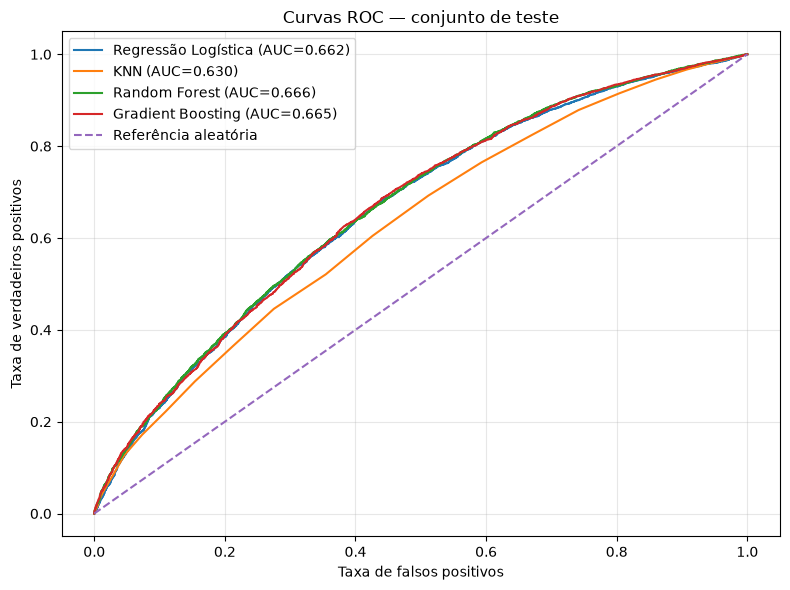

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for nome, probabilidades in probabilidades_teste.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilidades
    )

    auc = roc_auc_score(
        y_test,
        probabilidades
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{nome} (AUC={auc:.3f})"
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referência aleatória"
)

ax.set_title("Curvas ROC — conjunto de teste")
ax.set_xlabel("Taxa de falsos positivos")
ax.set_ylabel("Taxa de verdadeiros positivos")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "modelagem_curvas_roc_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 17. Curvas Precisão-Revocação — conjunto de teste


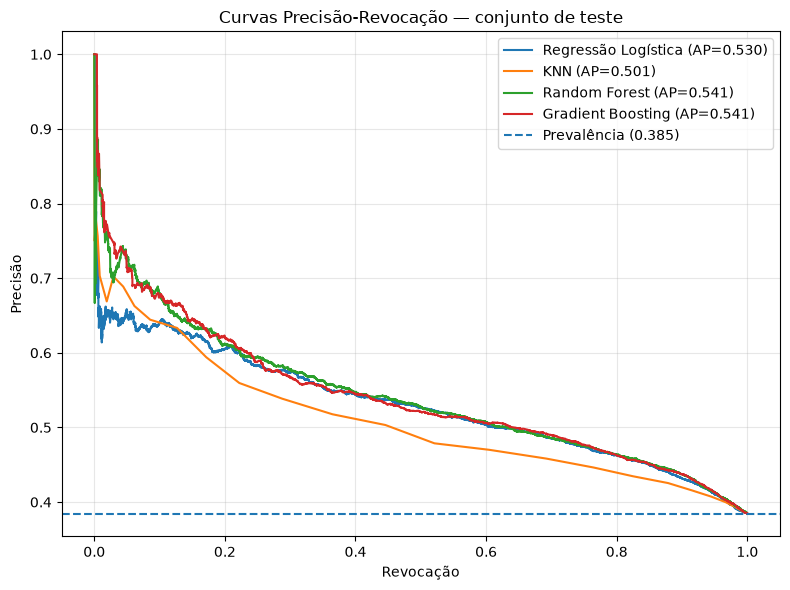

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

prevalencia_teste = y_test.mean()

for nome, probabilidades in probabilidades_teste.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilidades
    )

    ap = average_precision_score(
        y_test,
        probabilidades
    )

    ax.plot(
        recall,
        precision,
        label=f"{nome} (AP={ap:.3f})"
    )

ax.axhline(
    prevalencia_teste,
    linestyle="--",
    label=f"Prevalência ({prevalencia_teste:.3f})"
)

ax.set_title("Curvas Precisão-Revocação — conjunto de teste")
ax.set_xlabel("Revocação")
ax.set_ylabel("Precisão")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "modelagem_curvas_precision_recall_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 18. Comparação gráfica das métricas no teste

Este gráfico é descritivo. A escolha final do modelo não será realizada apenas com base em uma métrica isolada, pois o estudo prevê avaliação multidimensional.


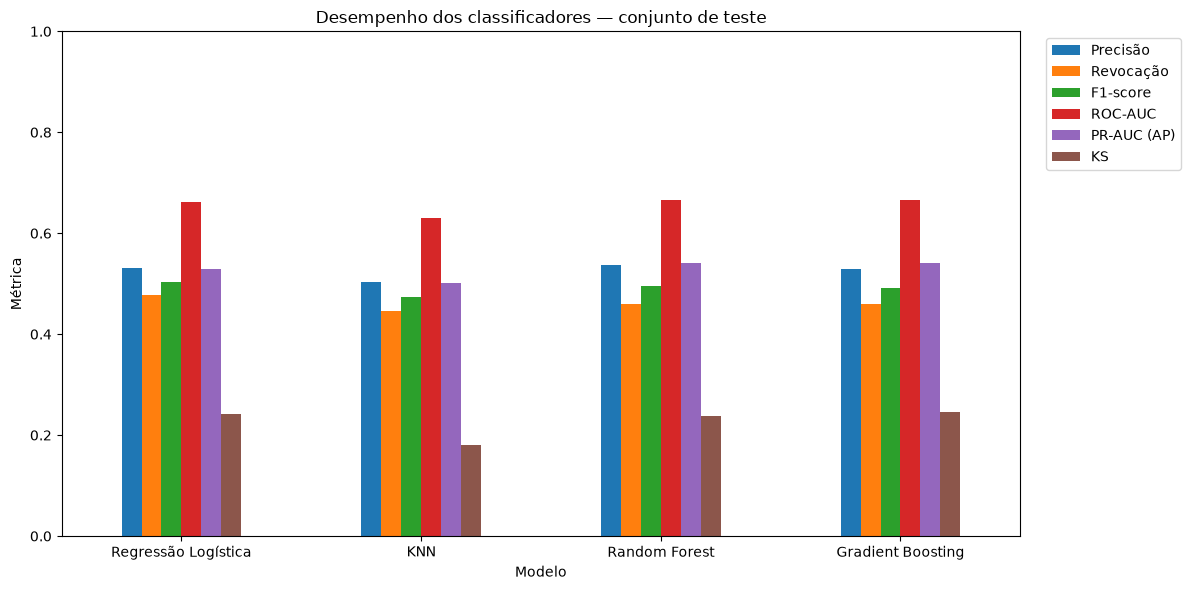

In [19]:
metricas_plot = (
    resultados_teste[
        [
            "Modelo",
            "Precisão",
            "Revocação",
            "F1-score",
            "ROC-AUC",
            "PR-AUC (AP)",
            "KS"
        ]
    ]
    .set_index("Modelo")
)

ax = metricas_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Desempenho dos classificadores — conjunto de teste")
ax.set_xlabel("Modelo")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "modelagem_metricas_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 19. Salvamento dos modelos ajustados

Os objetos salvos contêm o pré-processamento e o classificador ajustados utilizando todo o período de treino, após a seleção de hiperparâmetros pela validação temporal interna.

Esses objetos poderão ser utilizados posteriormente na avaliação do OOT.


In [20]:
modelos_finais_treino = {
    "regressao_logistica": busca_logistica.best_estimator_,
    "knn": busca_knn.best_estimator_,
    "random_forest": busca_rf.best_estimator_,
    "gradient_boosting": busca_gb.best_estimator_
}

for nome, modelo in modelos_finais_treino.items():
    caminho = (
        MODELS_DIR /
        f"modelo_treino_{nome}.joblib"
    )

    joblib.dump(
        modelo,
        caminho
    )

    print(f"Salvo: {caminho}")


Salvo: C:\UnB\script_md\outputs\modelos\modelo_treino_regressao_logistica.joblib
Salvo: C:\UnB\script_md\outputs\modelos\modelo_treino_knn.joblib
Salvo: C:\UnB\script_md\outputs\modelos\modelo_treino_random_forest.joblib
Salvo: C:\UnB\script_md\outputs\modelos\modelo_treino_gradient_boosting.joblib


## 20. Síntese automática

A síntese abaixo apresenta os resultados sem declarar um modelo final. A seleção definitiva deverá considerar conjuntamente o desempenho no teste, a avaliação OOT, a calibração, a estabilidade e a interpretabilidade.


In [21]:
maior_precision = resultados_teste.loc[
    resultados_teste["Precisão"].idxmax()
]

maior_pr_auc = resultados_teste.loc[
    resultados_teste["PR-AUC (AP)"].idxmax()
]

maior_roc_auc = resultados_teste.loc[
    resultados_teste["ROC-AUC"].idxmax()
]

print(
    f"No conjunto de teste, a maior Precisão no threshold 0,50 foi observada em "
    f"{maior_precision['Modelo']} ({maior_precision['Precisão']:.4f}). "
    f"A maior PR-AUC foi observada em {maior_pr_auc['Modelo']} "
    f"({maior_pr_auc['PR-AUC (AP)']:.4f}), enquanto a maior ROC-AUC foi observada em "
    f"{maior_roc_auc['Modelo']} ({maior_roc_auc['ROC-AUC']:.4f})."
)

print()

print(
    f"A especificação do KNN selecionada exclusivamente pela validação temporal do treino foi: "
    f"{especificacao_knn}."
)

print()

print(
    "Esses resultados representam a comparação inicial no conjunto de teste. "
    "Nenhuma informação do conjunto OOT foi utilizada no desenvolvimento, "
    "no pré-processamento ou na seleção dos hiperparâmetros."
)


No conjunto de teste, a maior Precisão no threshold 0,50 foi observada em Random Forest (0.5371). A maior PR-AUC foi observada em Gradient Boosting (0.5411), enquanto a maior ROC-AUC foi observada em Random Forest (0.6662).

A especificação do KNN selecionada exclusivamente pela validação temporal do treino foi: Sem Cidade.

Esses resultados representam a comparação inicial no conjunto de teste. Nenhuma informação do conjunto OOT foi utilizada no desenvolvimento, no pré-processamento ou na seleção dos hiperparâmetros.


## 21. Próxima etapa

A próxima etapa deverá avaliar os modelos no conjunto **out-of-time (OOT)**, mantendo os pipelines congelados.

Essa avaliação permitirá examinar:

- manutenção da Precisão, Revocação e F1;
- ROC-AUC, PR-AUC e KS em período posterior;
- degradação ou estabilidade temporal;
- efeito da alteração da prevalência da classe positiva;
- calibração;
- interpretabilidade dos modelos.

A seleção final deverá decorrer da avaliação multidimensional, e não de uma única métrica no conjunto de teste.
